# 03 — Backends Tour: `:adaptive_cartesian` vs `:lifted_pair`

Three runs of the canonical 2D problem from `common.jl`, differing only in regularization setup:

1. **Unregularized** — baseline.
2. **`:adaptive_cartesian`** — adaptive Cartesian substepping near periapsis.
3. **`:lifted_pair`** — true 2D Levi-Civita lifted pair (only available in 2D).

Then a small `r_on_factor` sweep with `:lifted_pair` to show how the activation threshold trades substep count, constraint quality, and energy drift.

In [1]:
include(joinpath(@__DIR__, "common.jl"))

## 1. Three runs

In [2]:
prob_none     = canonical_2d_problem()
prob_adaptive = canonical_2d_problem(
    regularization = RegularizationOptions(
        enabled = true, backend = :adaptive_cartesian, r_on = 0.5, r_off = 0.7,
    ),
)
prob_lifted   = canonical_2d_problem(
    regularization = RegularizationOptions(
        enabled = true, backend = :lifted_pair, r_on = 0.5, r_off = 0.7,
    ),
)

sol_none     = solve(prob_none)
sol_adaptive = solve(prob_adaptive)
sol_lifted   = solve(prob_lifted)

print_reg_diagnostics(sol_none;     label = "none")
println()
print_reg_diagnostics(sol_adaptive; label = "adaptive")
println()
print_reg_diagnostics(sol_lifted;   label = "lifted")

[none] retcode                  = Success
[none] requested_backend        = disabled


[none] used_backend             = disabled
[none] active_steps             = 0
[none] pair_steps               = 0
[none] adaptive_pair_steps      = 0
[none] lifted_pair_steps        = 0
[none] chain_steps              = 0
[none] unregularized_steps      = 27141
[none] backend_fallback_steps   = 0
[none] total_substeps           = 27141
[none] max_substeps_used        = 1
[none] activation_count         = 0
[none] deactivation_count       = 0
[none] min_encounter_distance   = Inf
[none] max_constraint_violation = 0.000e+00

[adaptive] retcode                  = Success
[adaptive] requested_backend        = adaptive_cartesian
[adaptive] used_backend             = adaptive_cartesian
[adaptive] active_steps             = 2311
[adaptive] pair_steps               = 2311
[adaptive] adaptive_pair_steps      = 2311
[adaptive] lifted_pair_steps        = 0
[adaptive] chain_steps              = 0
[adaptive] unregularized_steps      = 24830
[adaptive] backend_fallback_steps   = 0
[adaptive] total_

## 2. Trajectories side-by-side

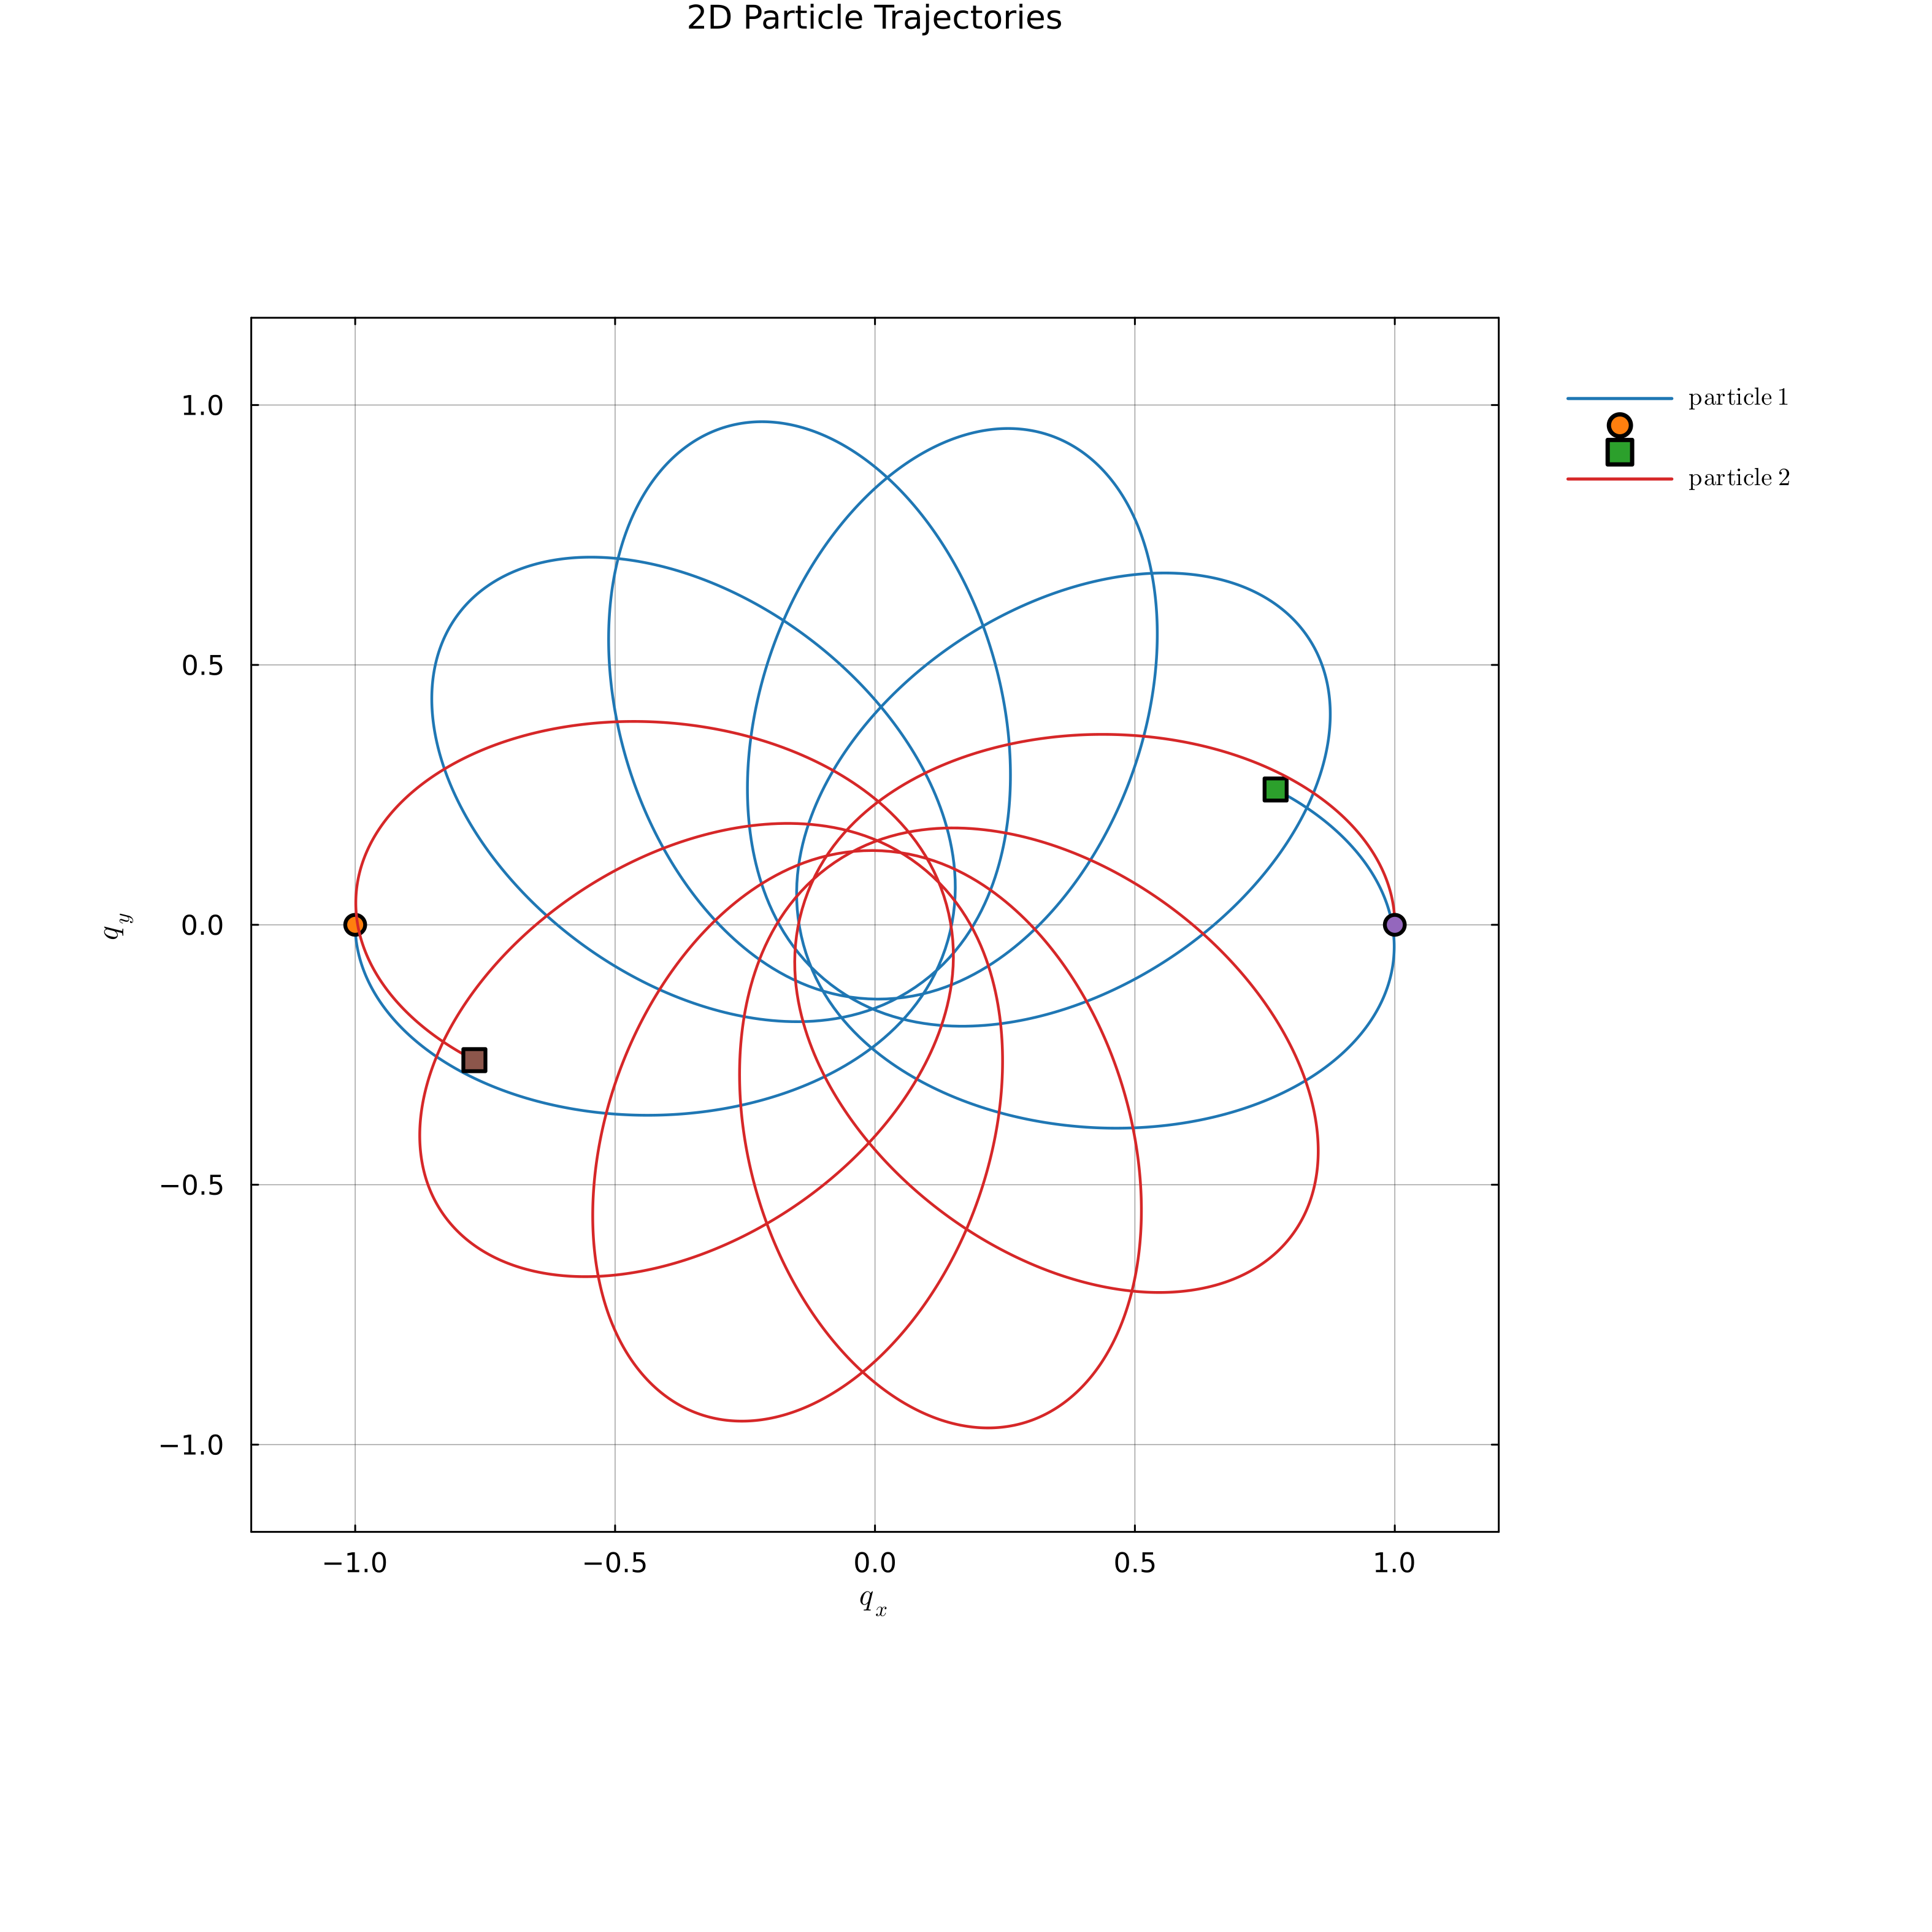

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [3]:
plot_trajectories(compute_trajectory_data(sol_none,     2, 2; stride = 10))

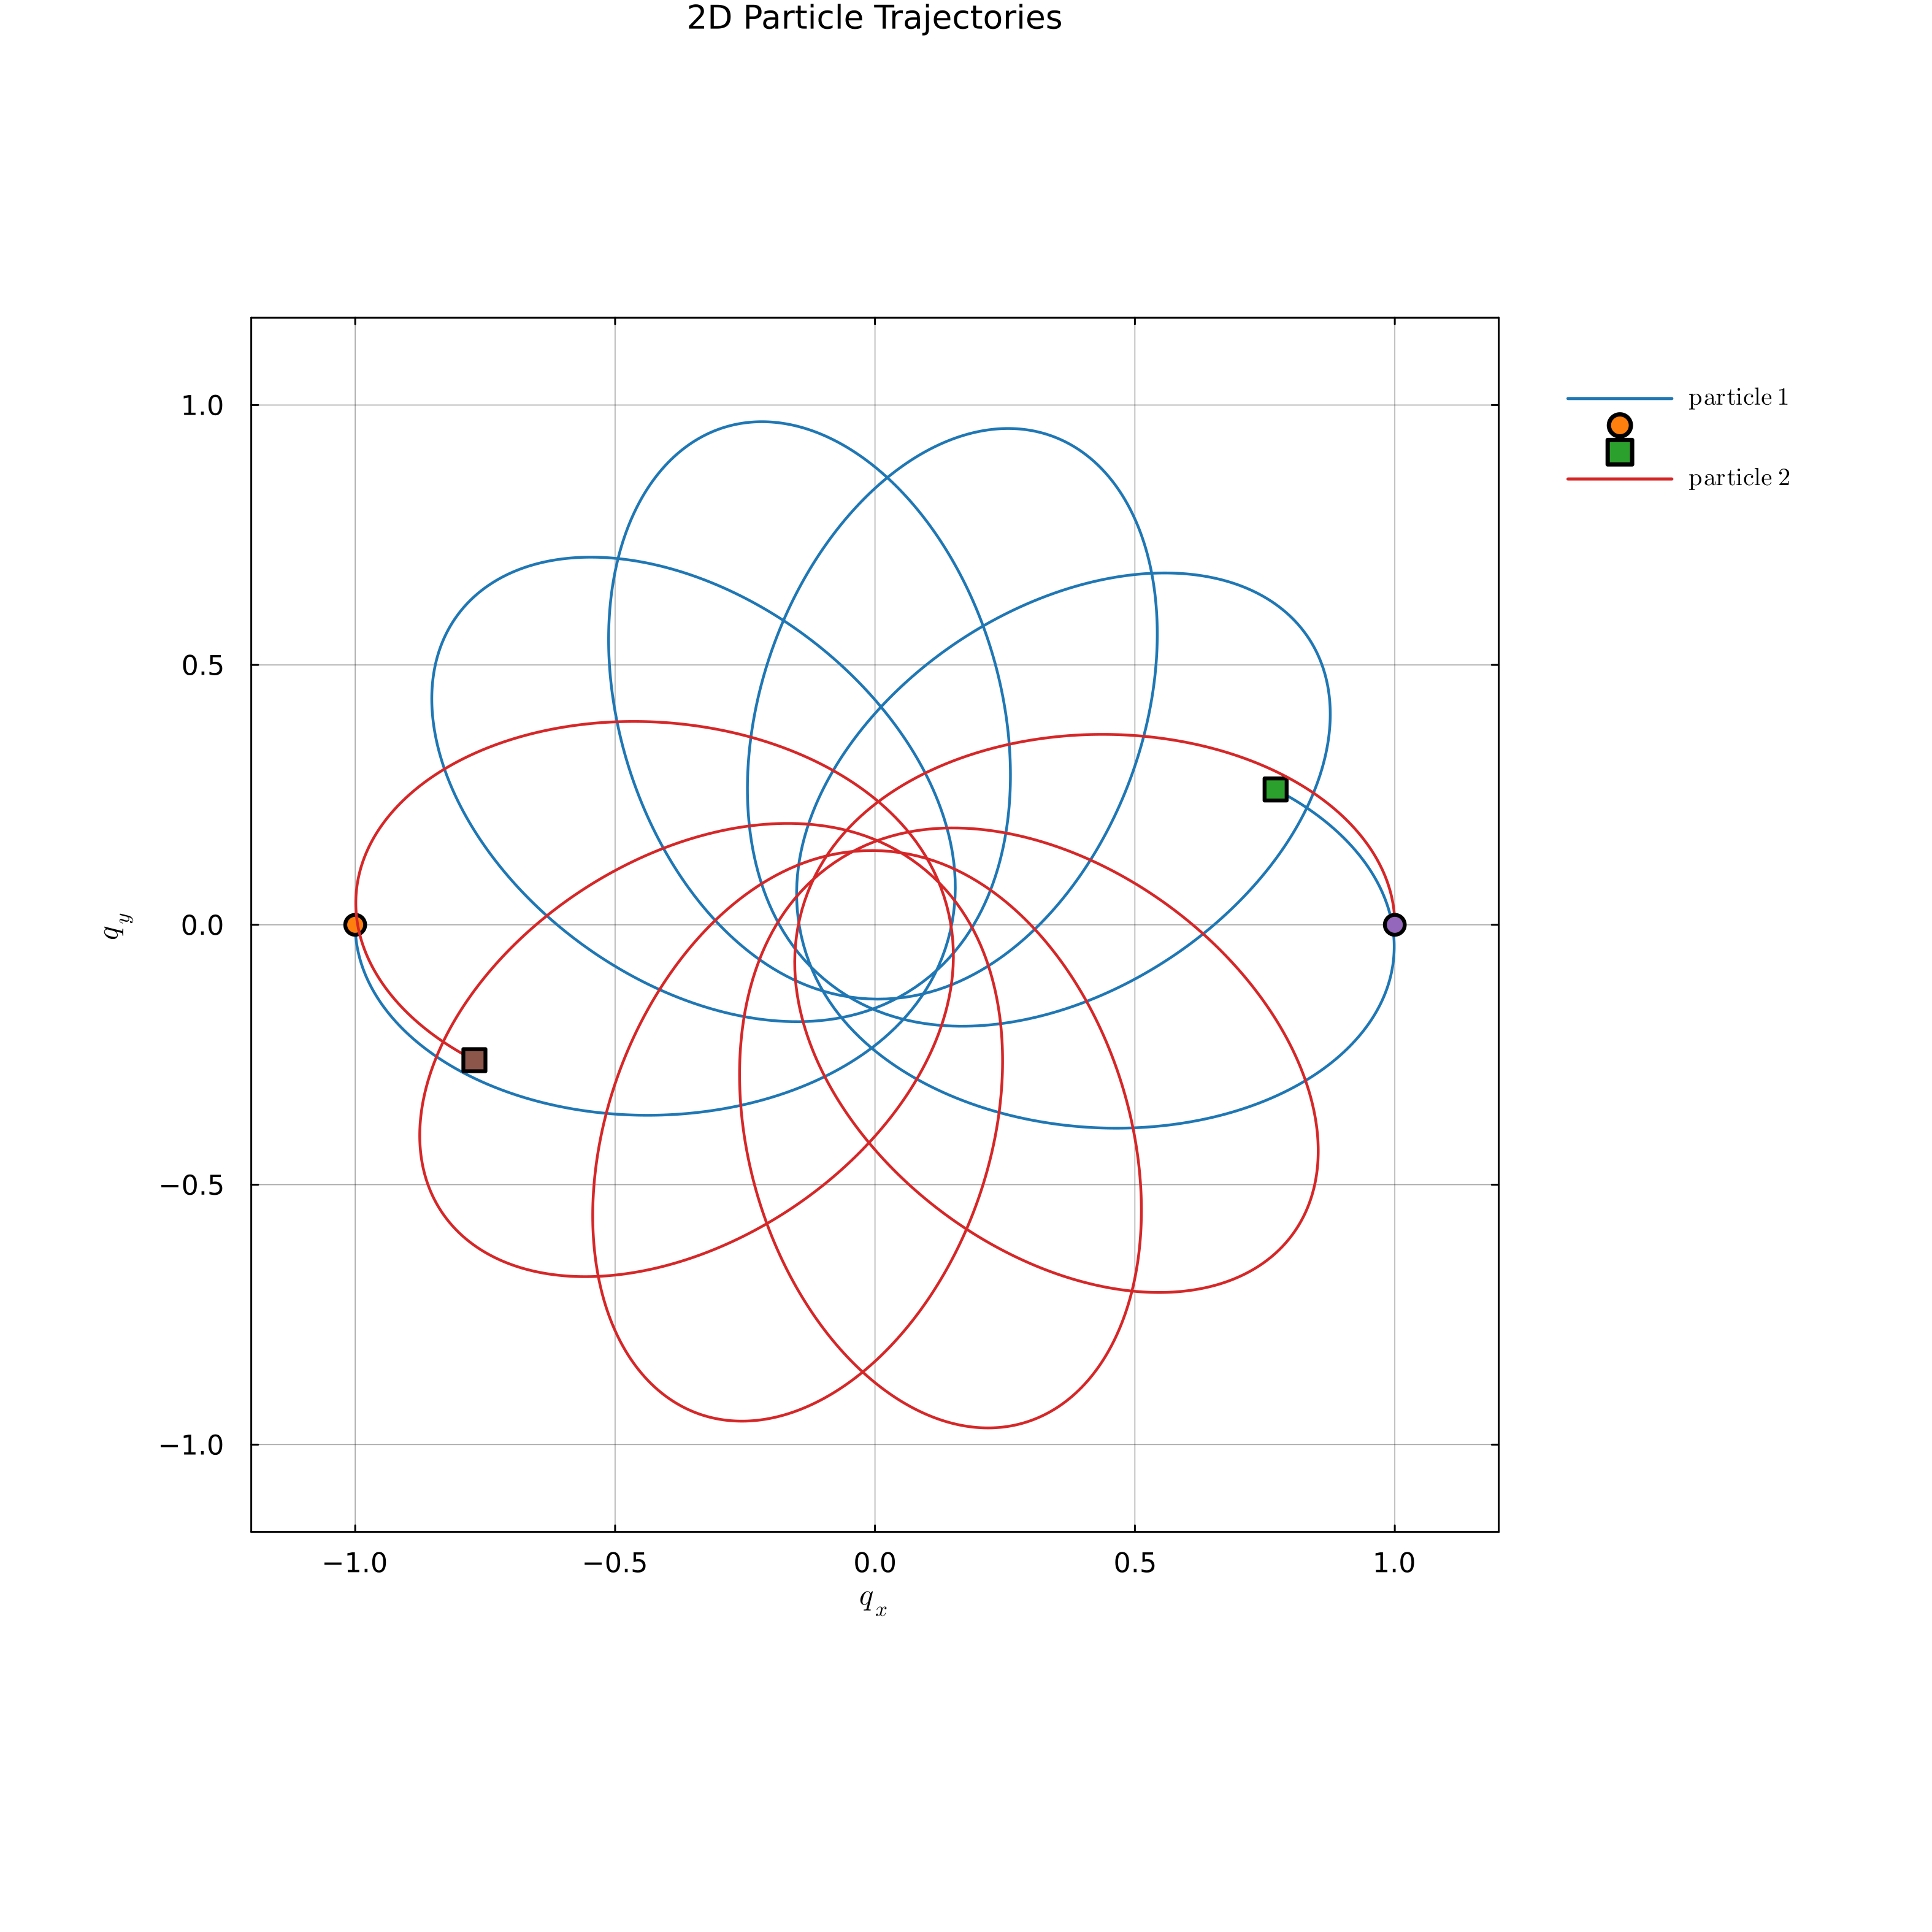

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [4]:
plot_trajectories(compute_trajectory_data(sol_adaptive, 2, 2; stride = 10))

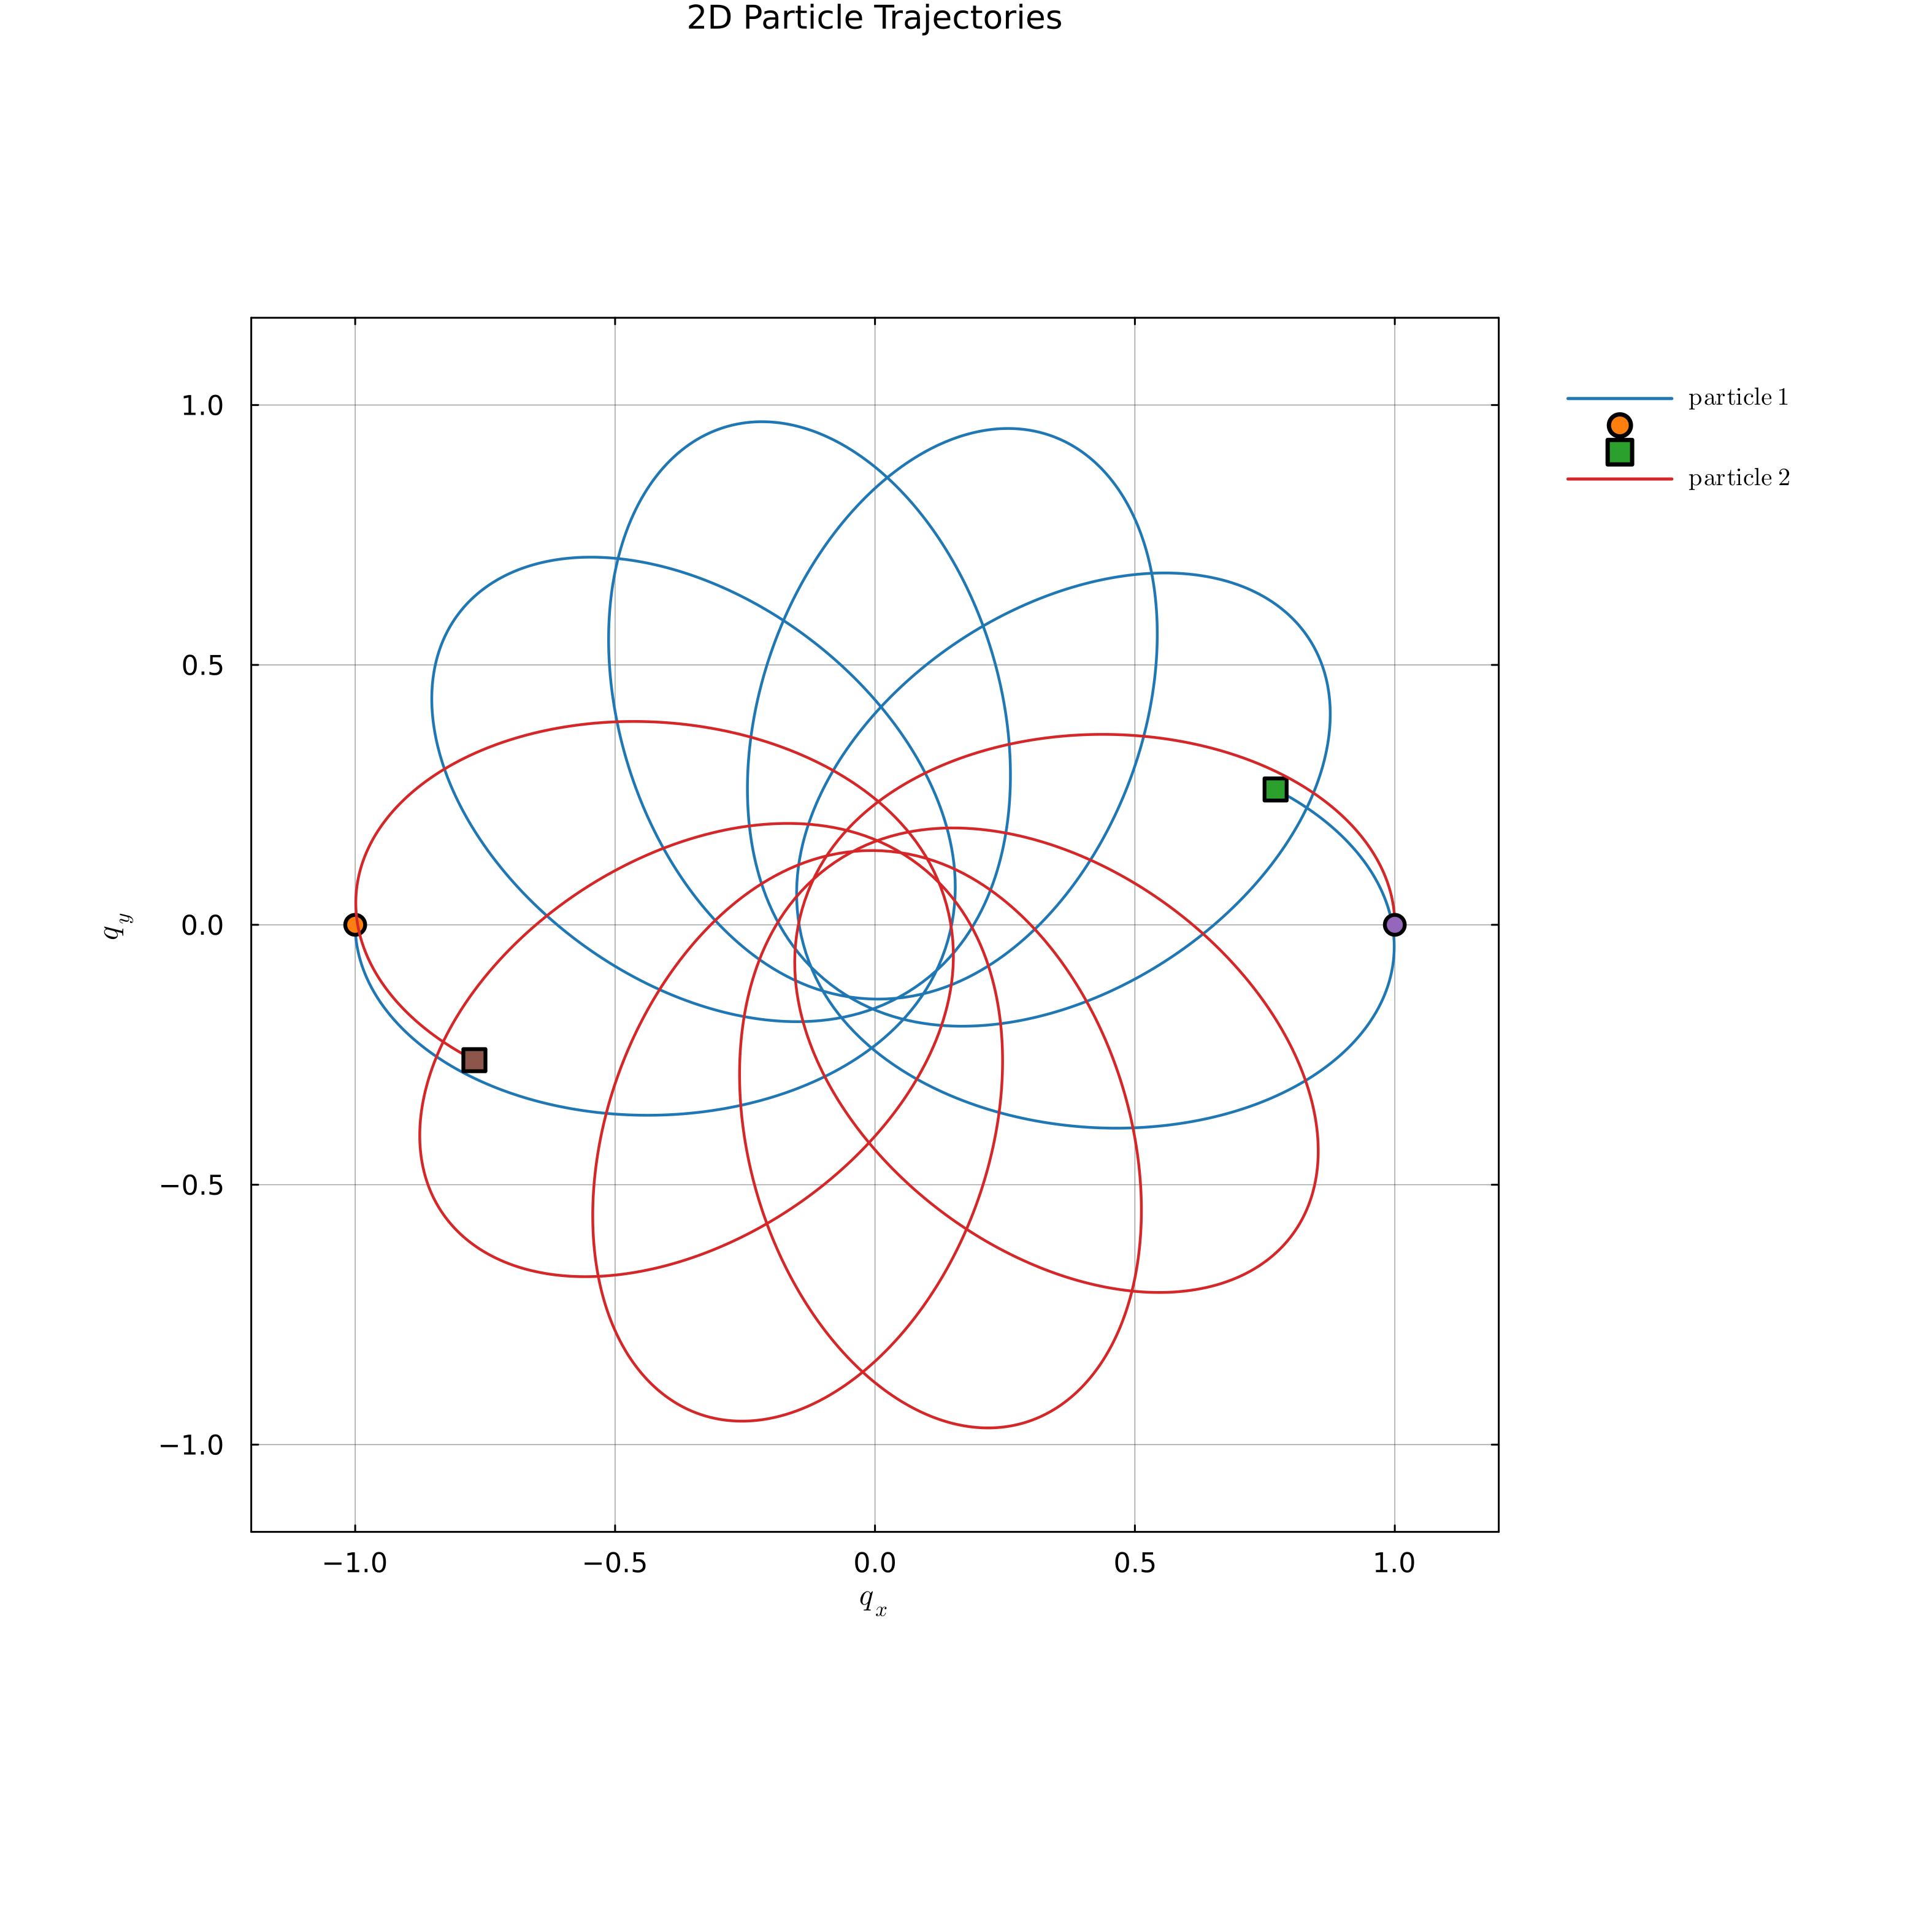

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [5]:
plot_trajectories(compute_trajectory_data(sol_lifted,   2, 2; stride = 10))

## 3. Energy errors side-by-side

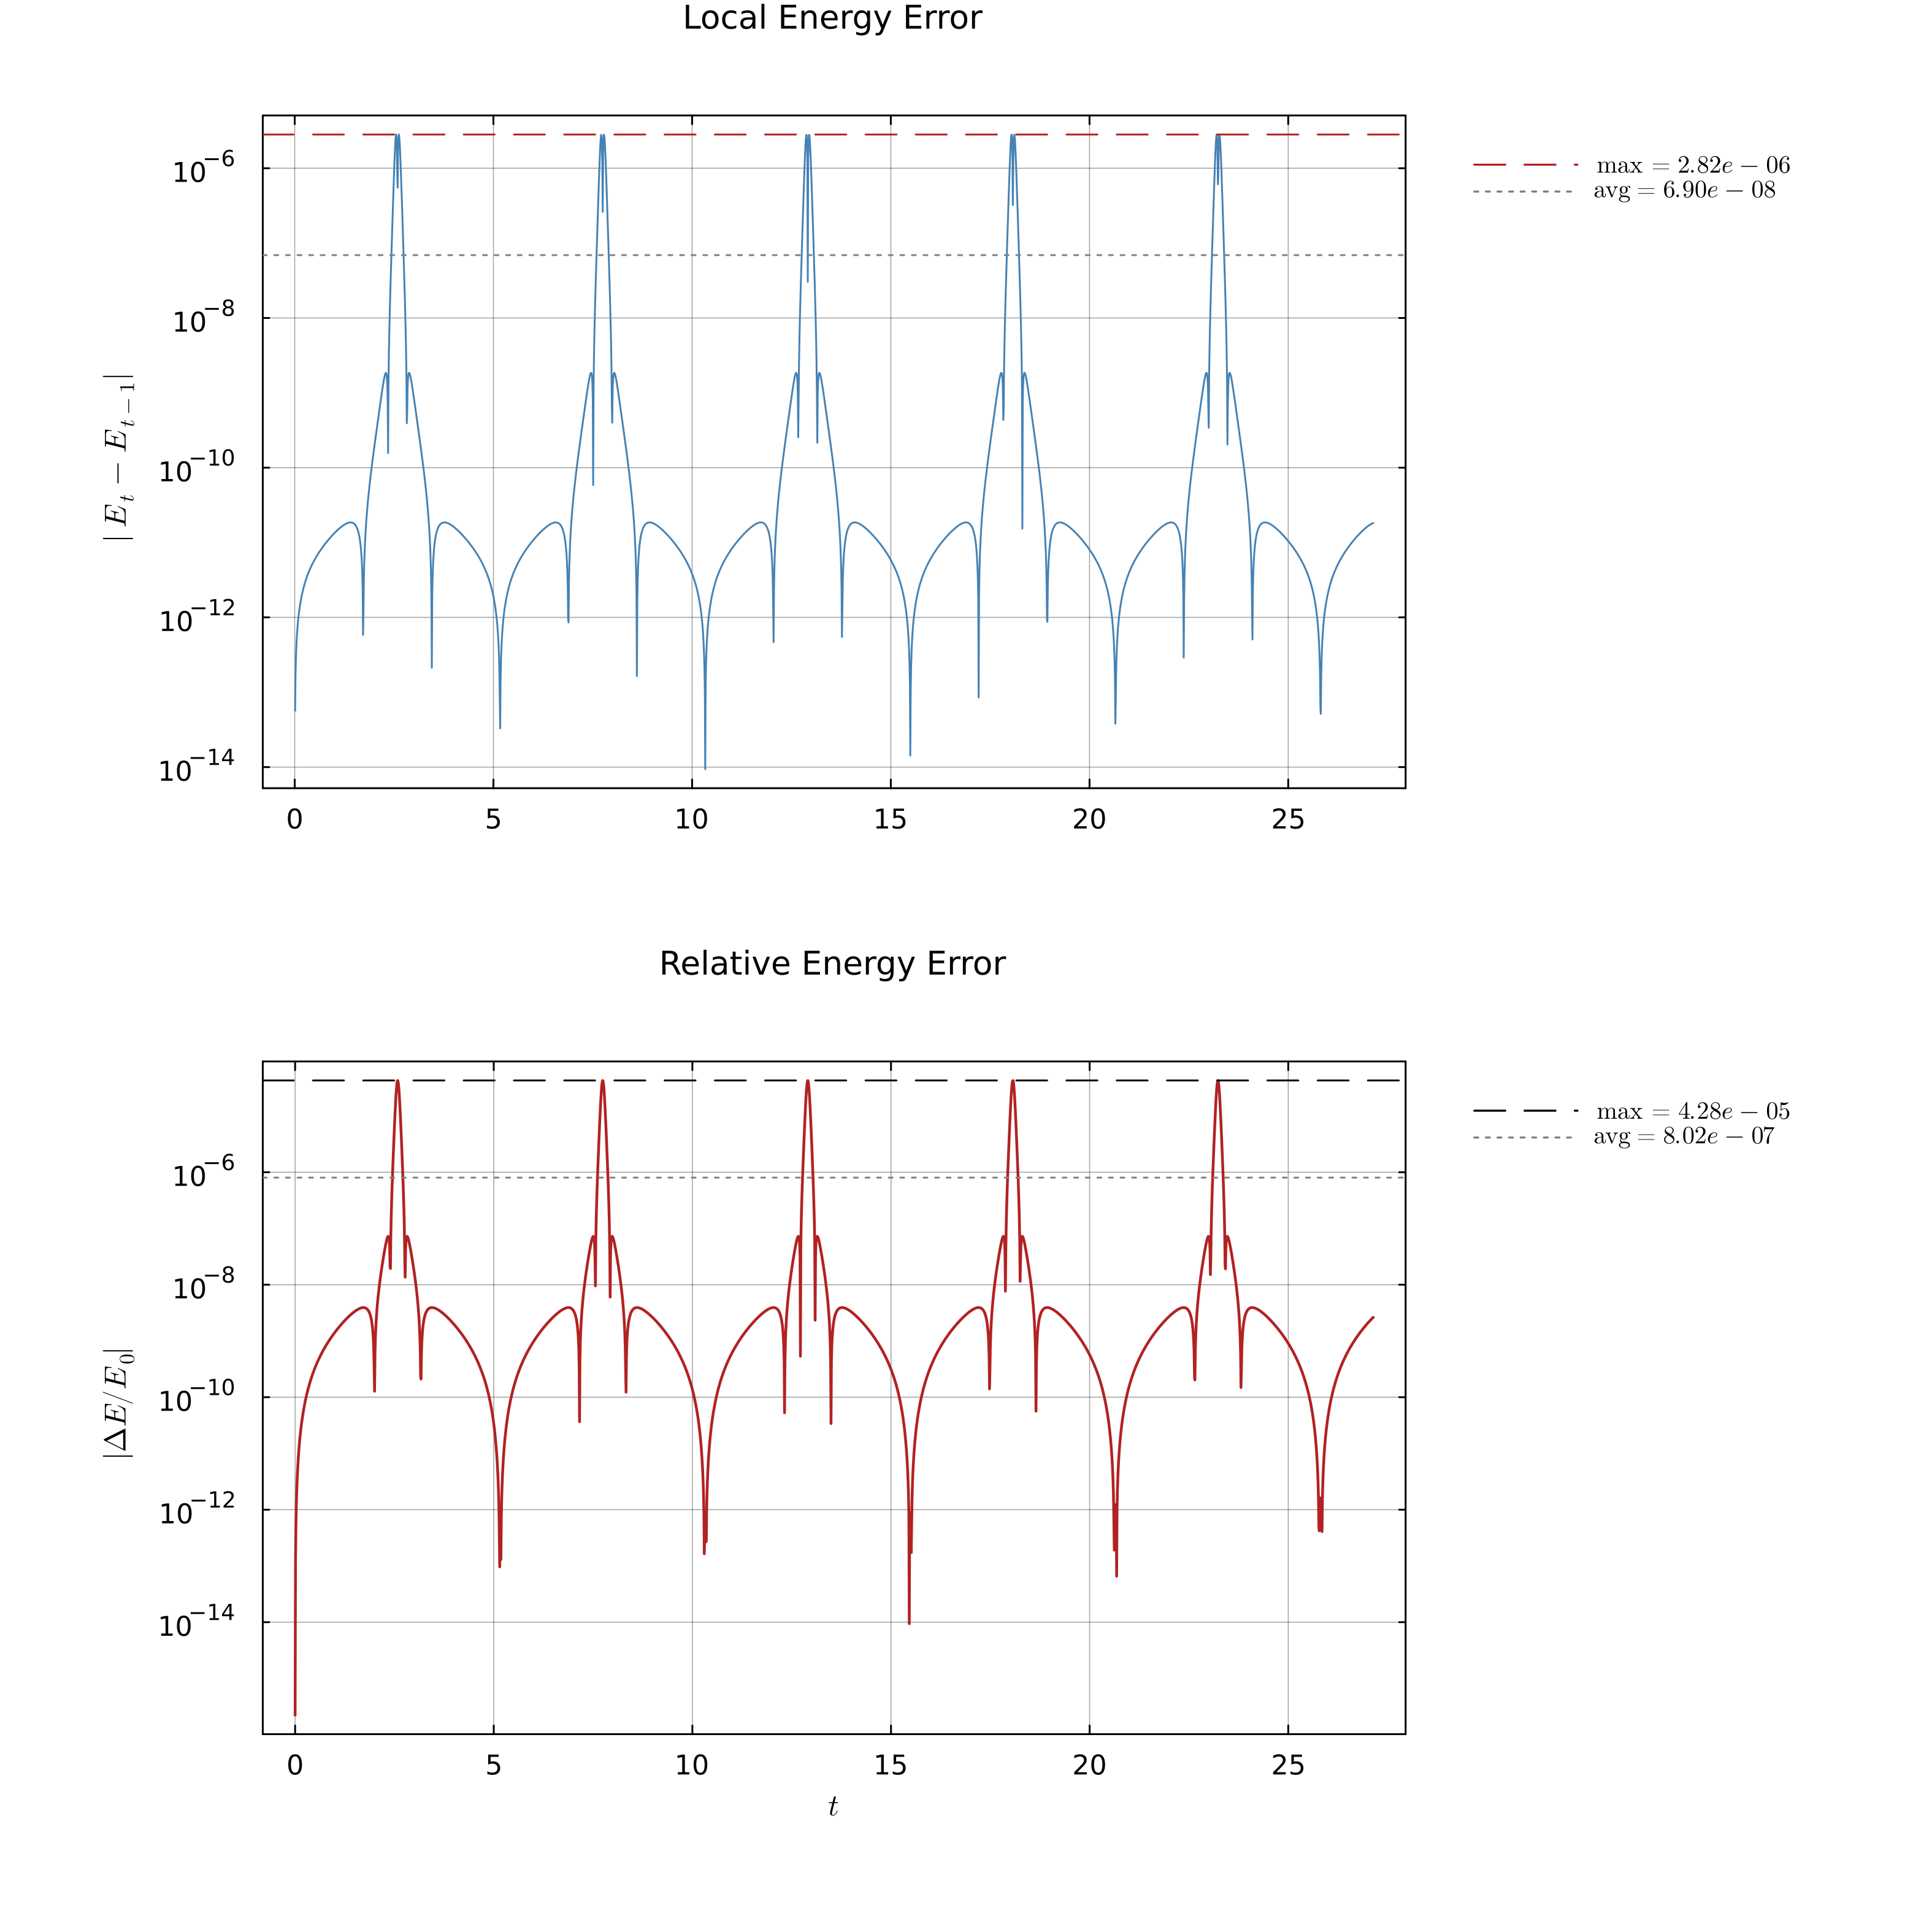

In [6]:
en_none     = compute_energy_timeseries(sol_none;     stride = 10)
en_adaptive = compute_energy_timeseries(sol_adaptive; stride = 10)
en_lifted   = compute_energy_timeseries(sol_lifted;   stride = 10)

plot_energy_errors(en_none)

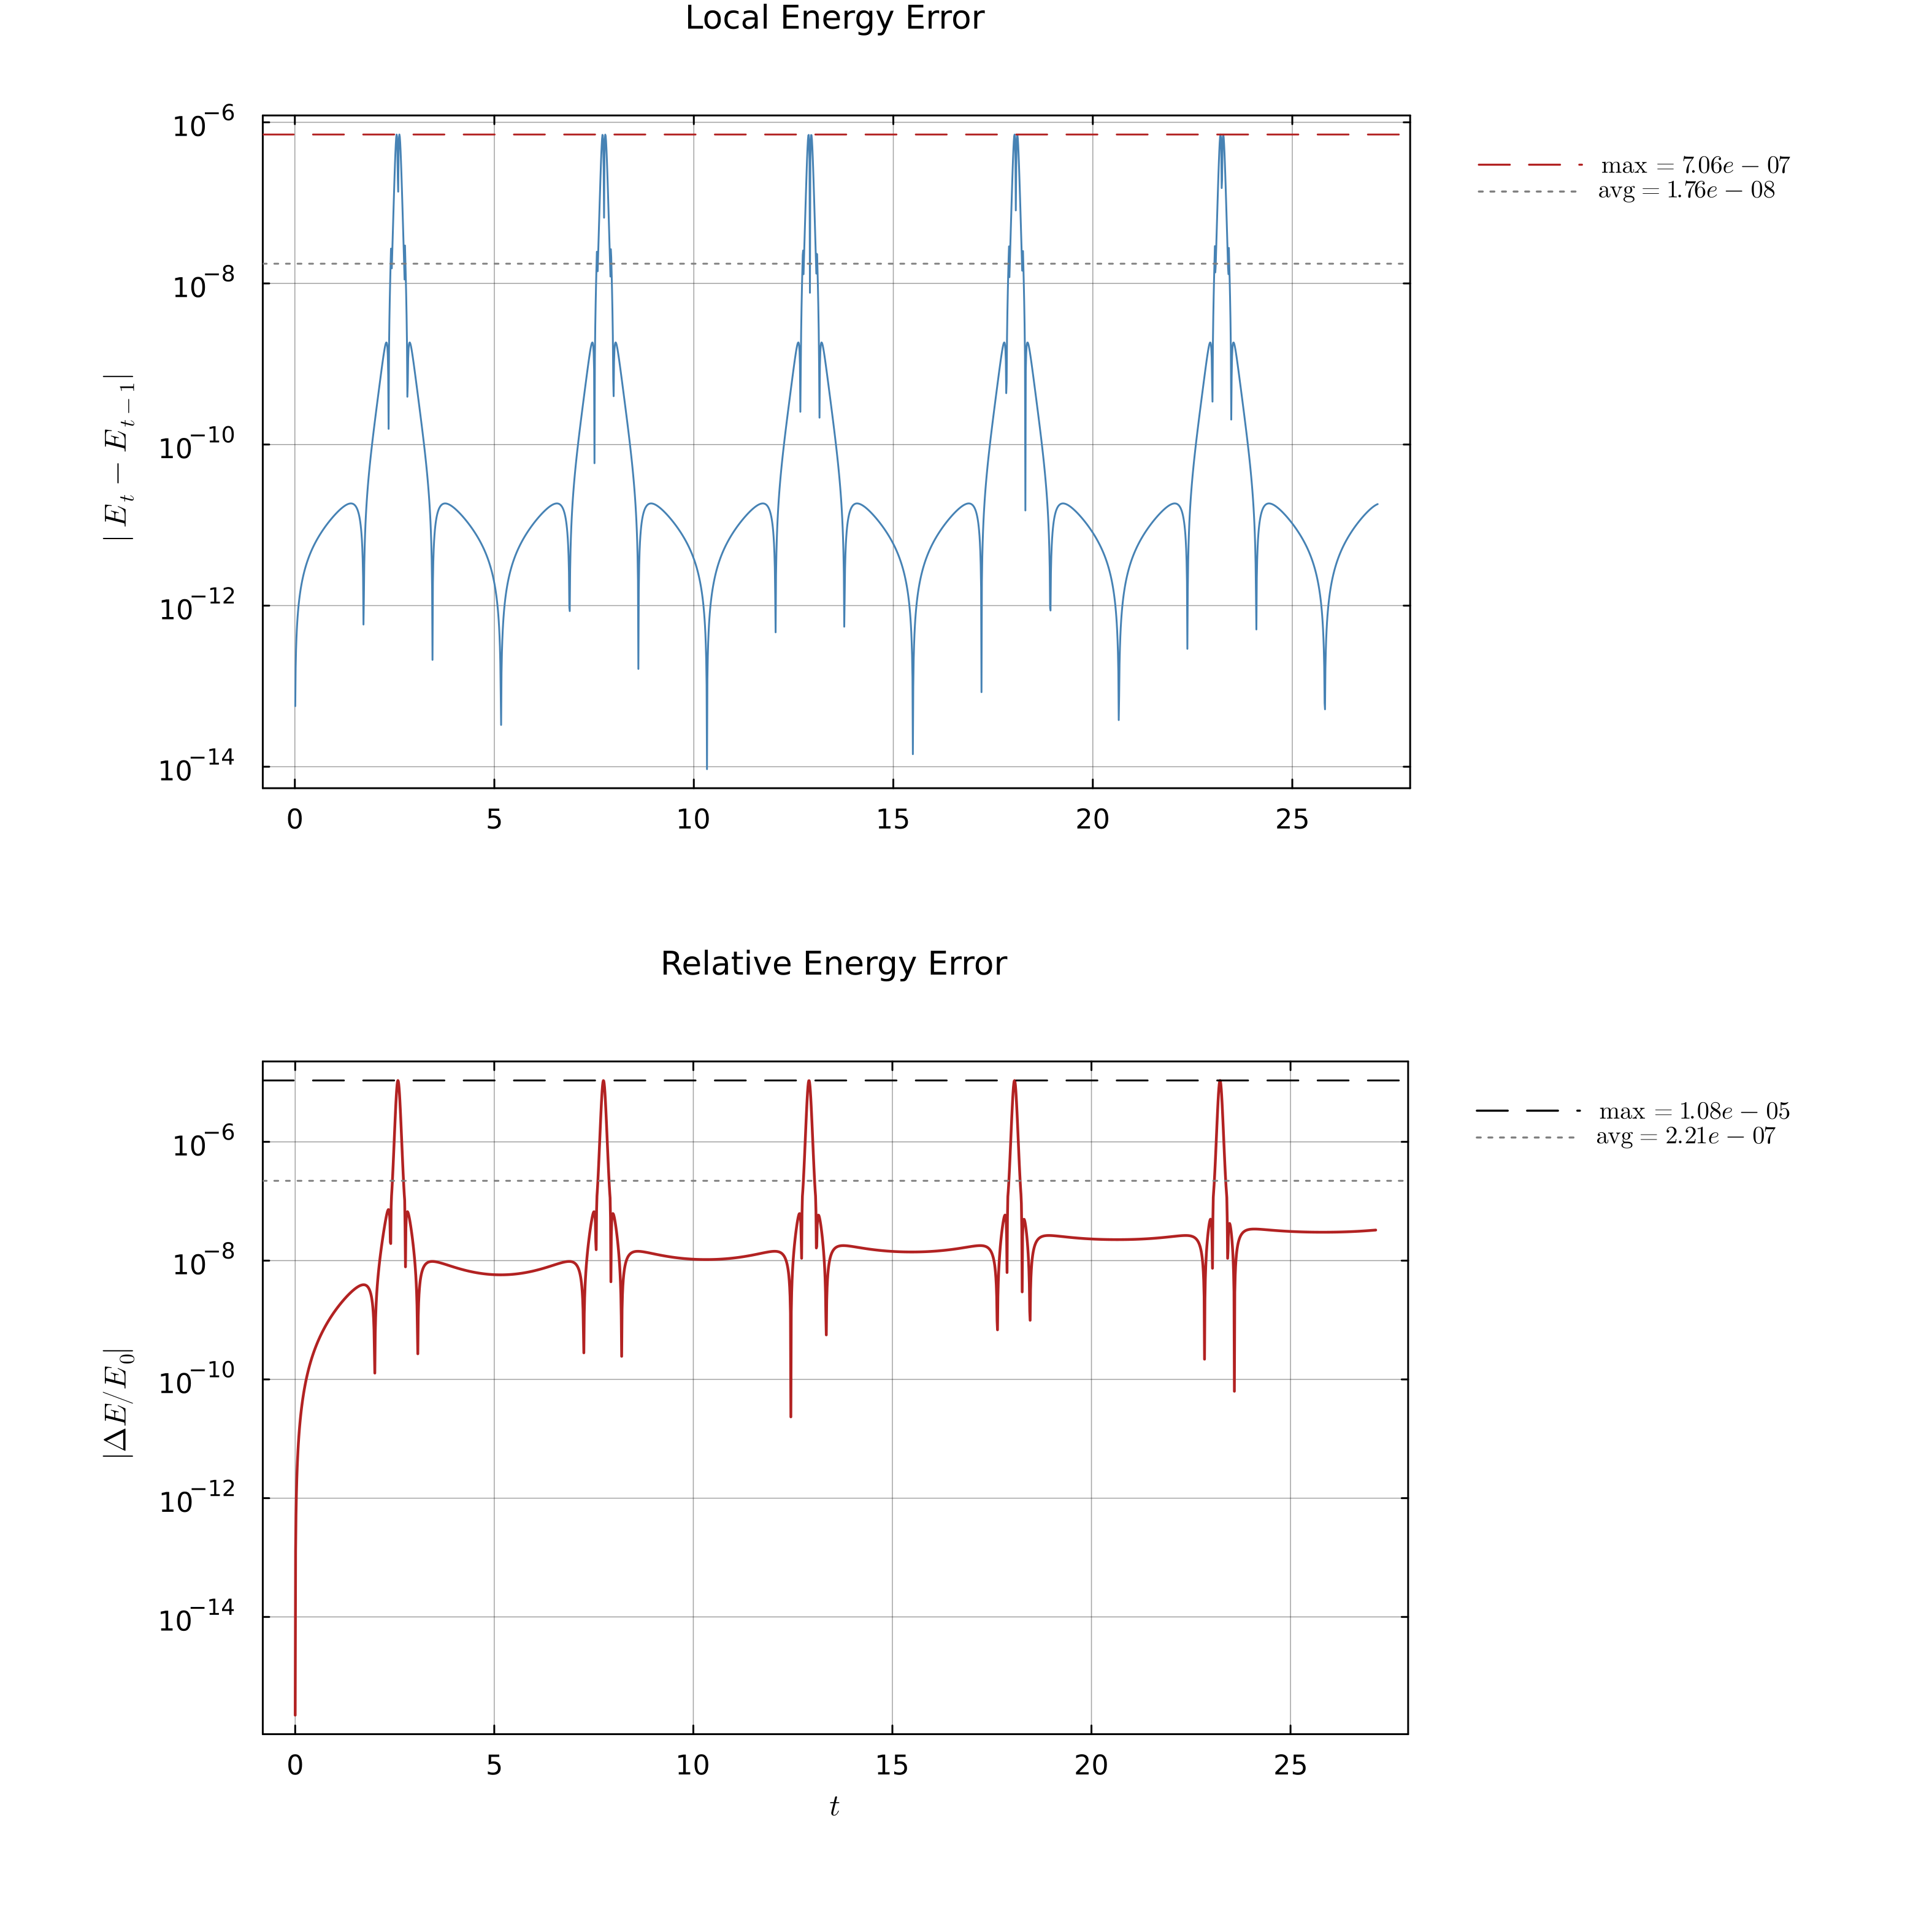

In [7]:
plot_energy_errors(en_adaptive)

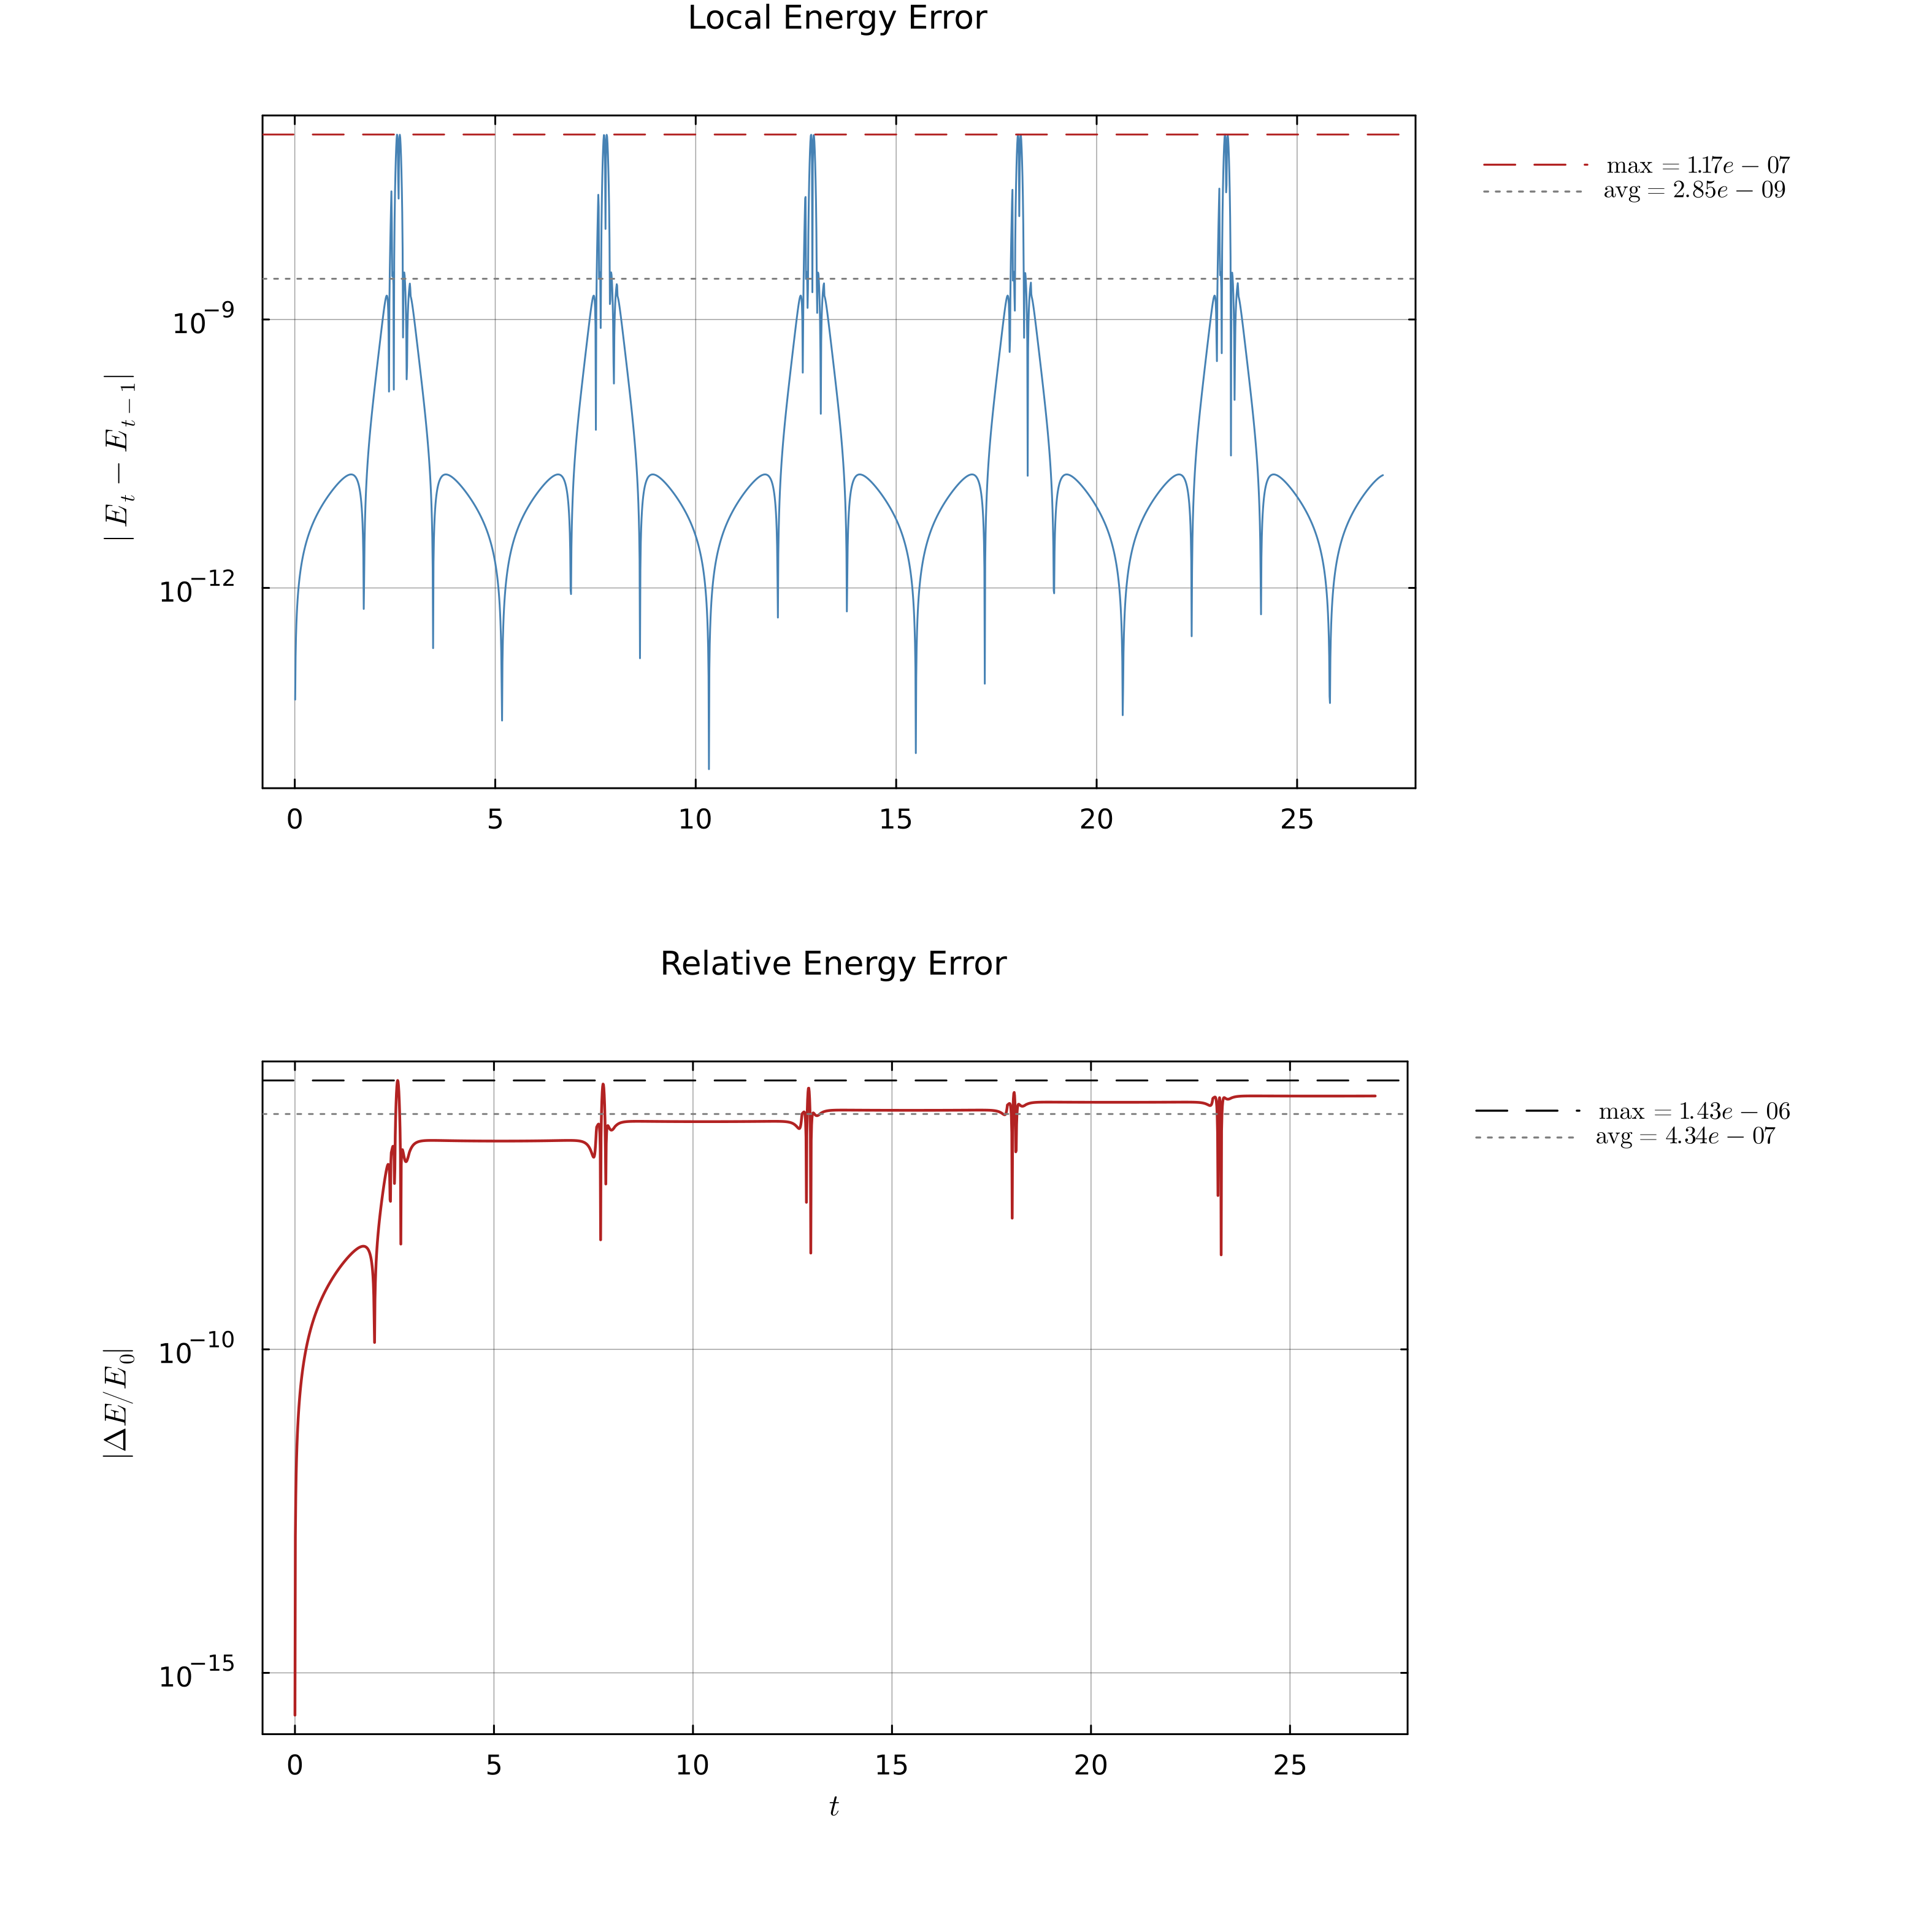

In [8]:
plot_energy_errors(en_lifted)

## 4. Momentum errors side-by-side

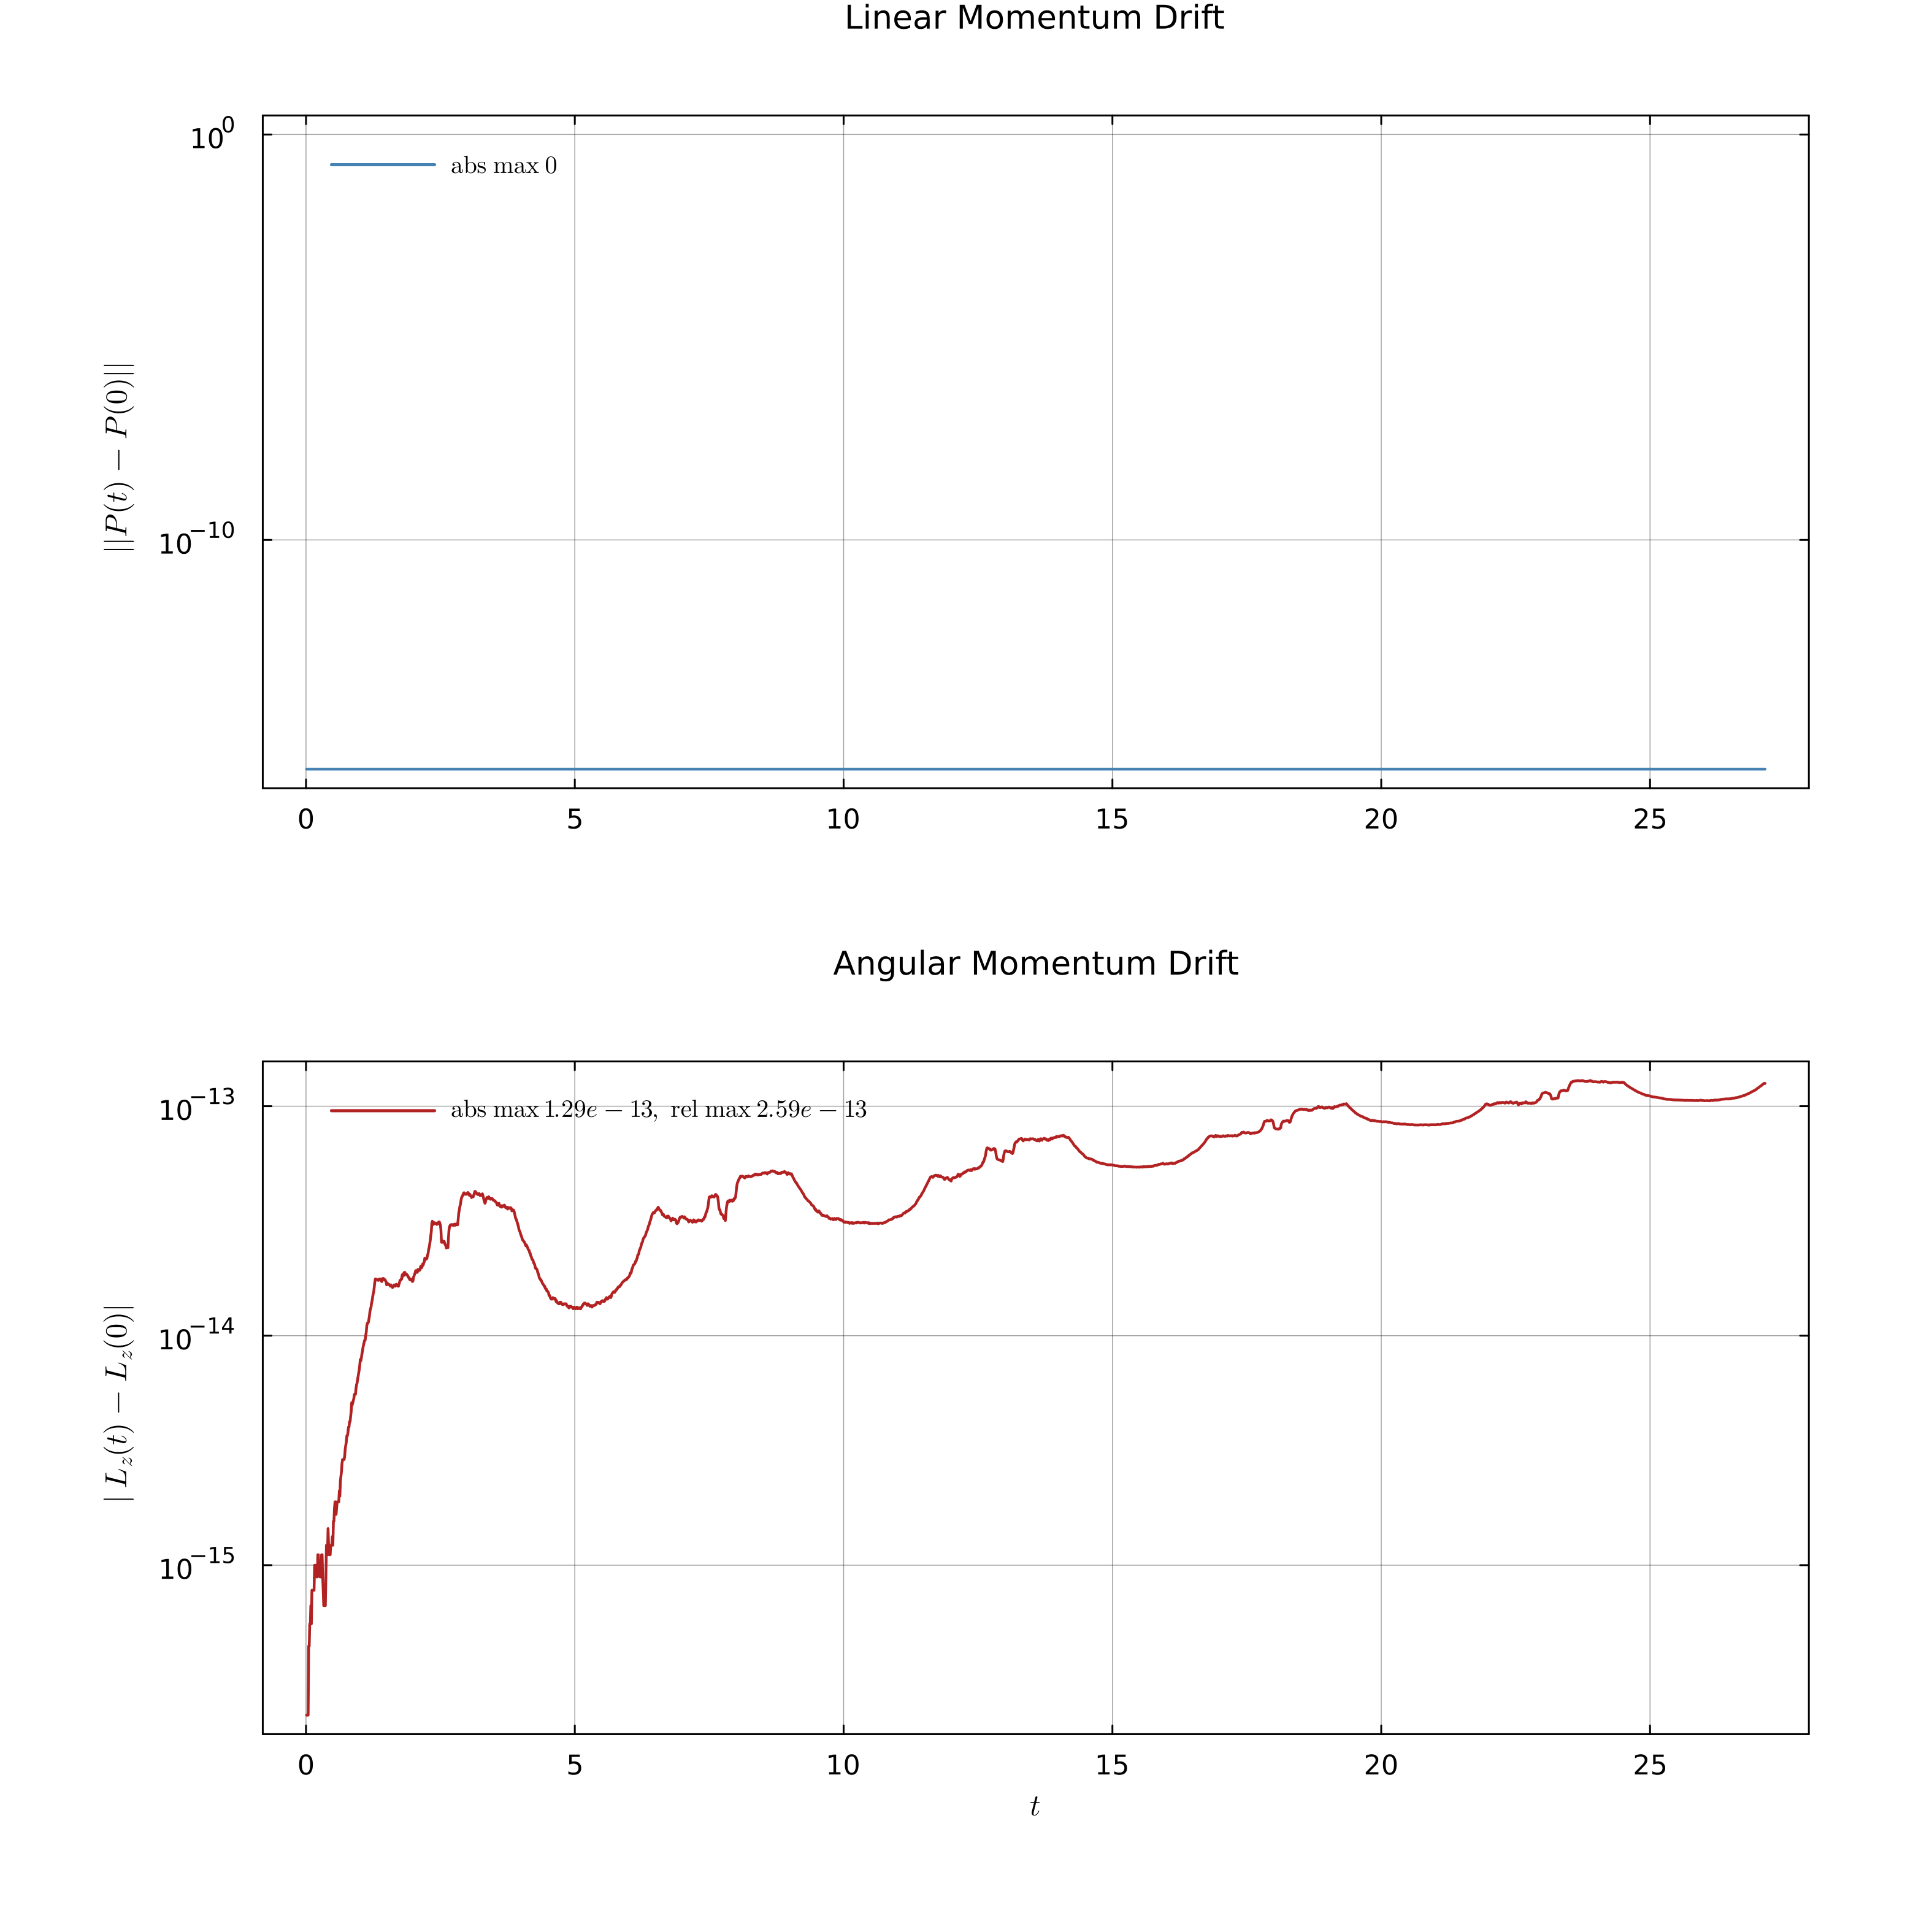

In [9]:
plot_momentum_errors(compute_momentum_timeseries(sol_none;     stride = 10))

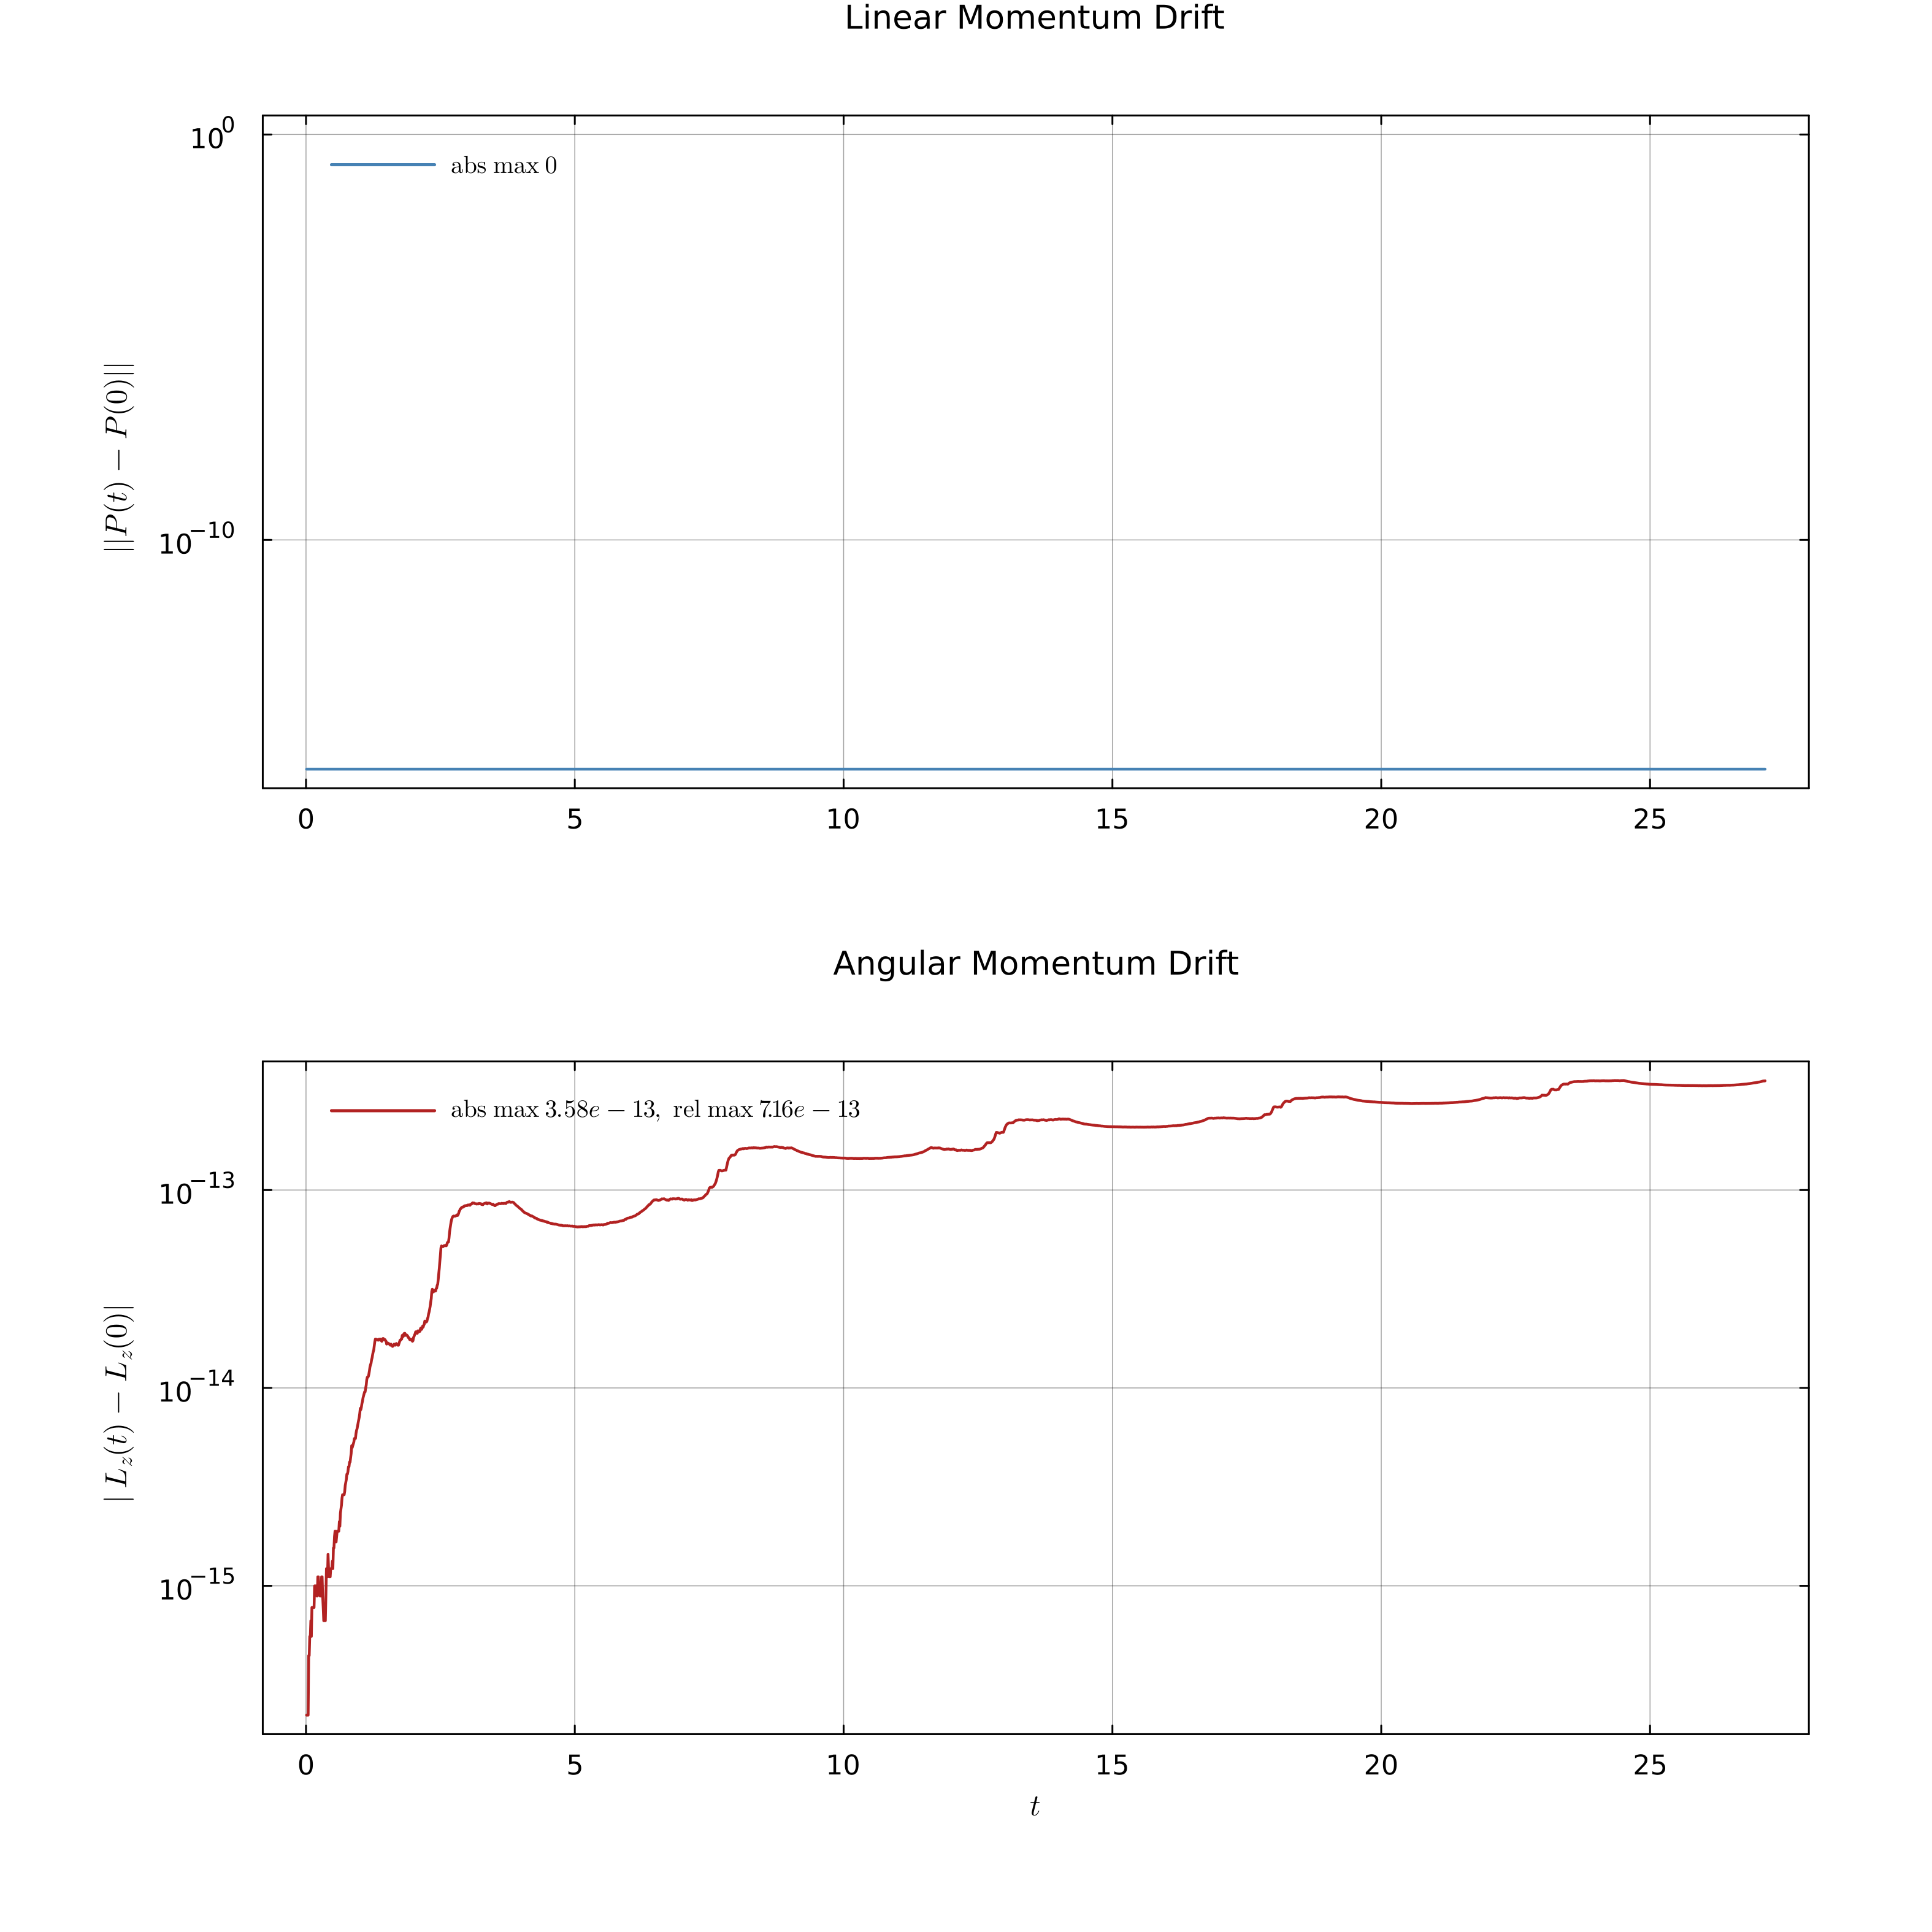

In [10]:
plot_momentum_errors(compute_momentum_timeseries(sol_adaptive; stride = 10))

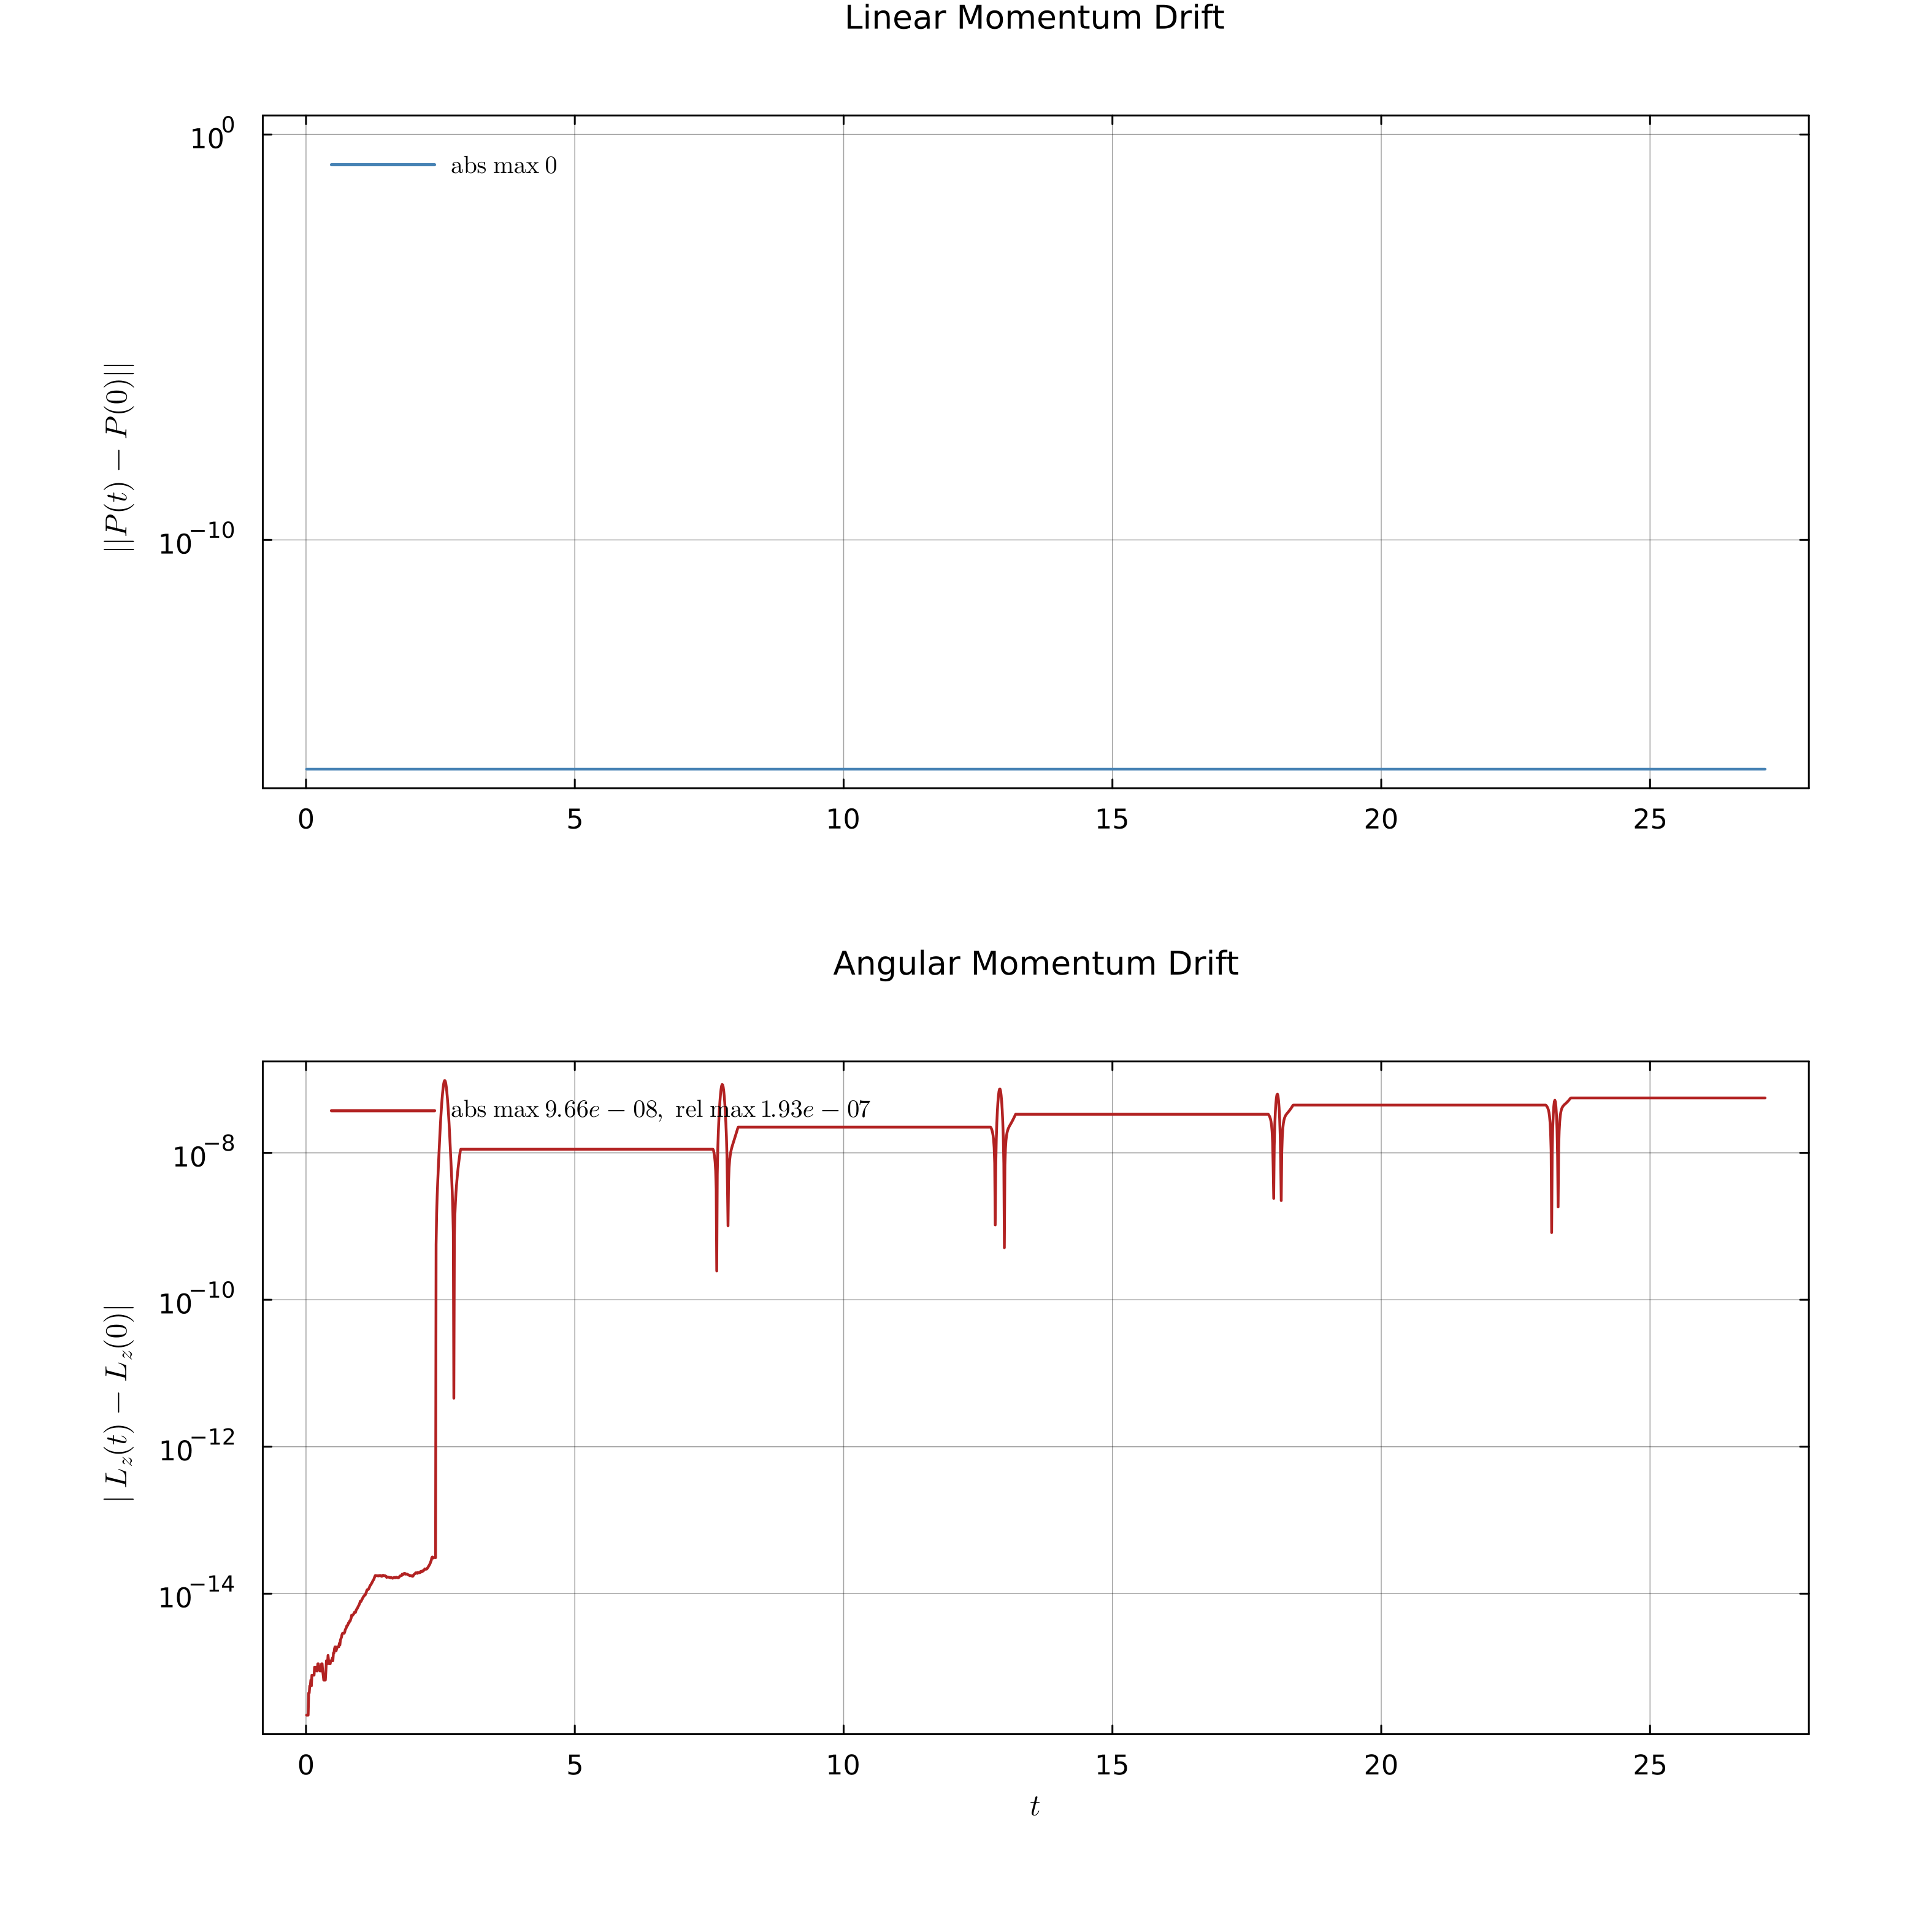

In [11]:
plot_momentum_errors(compute_momentum_timeseries(sol_lifted;   stride = 10))

## 5. `r_on_factor` sweep with `:lifted_pair`

Hold everything else fixed and vary the activation threshold. We expect: smaller `r_on_factor` → lifted pair active only in a tiny window around periapsis → fewer `lifted_pair_steps` and lower `total_substeps`, but perhaps worse energy drift because the hardest part of each periapsis is handled without the regularized chart. Larger factor → reg active for longer → more work, usually better drift.

In [12]:
factors = [0.1, 0.2, 0.3, 0.5, 1.0]

@printf("%-10s %-12s %-12s %-12s %-14s %-14s\n",
    "r_on_fac", "pair_steps", "lifted", "substeps", "max_subs", "drift_%")
println(repeat("-", 78))

for f in factors
    prob = canonical_2d_problem(
        regularization = RegularizationOptions(
            enabled = true, backend = :lifted_pair, r_on_factor = f, r_off_factor = f + 0.1,
        ),
    )
    sol = solve(prob)
    en  = compute_energy_timeseries(sol; stride = 20)
    d   = sol.regularization
    @printf("%-10.2f %-12d %-12d %-12d %-14d %-14.3e\n",
        f, d.pair_steps, d.lifted_pair_steps, d.total_substeps,
        d.max_substeps_used, en.statistics.global_error_percent_max)
end

r_on_fac   pair_steps   lifted       substeps     max_subs       drift_%       
------------------------------------------------------------------------------
0.10       0            0            27141        1              4.279e-03     


0.20       1690         1690         29166        3              1.100e-03     
0.30       2960         2960         31826        4              1.206e-04     
0.50       6100         6100         39468        6              4.580e-05     
1.00       27141        27141        80463        11             1.289e-05     


## 6. Takeaways

- Both regularized backends reproduce the Kepler ellipse; the visual trajectories are indistinguishable at this scale.
- `:lifted_pair` typically achieves the lowest energy drift on well-conditioned 2D problems because it handles the periapsis analytically in $(u, U)$ coordinates rather than via adaptive substepping.
- The sweep shows the activation threshold is a genuine knob: for a mild periapsis ($r_{\text{peri}} \approx 0.29$) a moderate factor (0.3–0.5) is usually enough.
- For 3D or non-trivial encounter topology, `:adaptive_cartesian` is the backend that actually runs (see [`07_3d_close_encounter.ipynb`](07_3d_close_encounter.ipynb)).